Universidad del Valle de Guatemala  
Departamento de Ciencias de la Computación  
Data Science - sección 40

Cristian Túnchez (231359)  
Nadissa López (23764)

# Laboratorio 4 — Parte 2: Análisis de la cianobacteria

Este notebook cubre los **ejercicios 4 al 8** del laboratorio:

4. Análisis temporal del índice de cianobacteria.
5. Análisis espacial y mapas comparativos.
6. Correlación de NDVI y NDWI con la presencia de cianobacteria.
7. Análisis y comparación entre los dos lagos.
8. Análisis exploratorio adicional.

Inicia a partir de los productos generados en `01_obtencion_de_datos.ipynb` y guardados en `data/processed/`:
- GeoTIFF de índices por lago y fecha
- La máscara fija de cada lago
- La tabla `estadisticas_por_fecha.csv`

In [1]:
import sys
import warnings
from pathlib import Path

import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sys.path.insert(0, str(Path.cwd().parent / "src"))

import config
import mapas as mp
import procesar

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

LAGOS = list(config.FECHAS)
COLOR = {"Atitlan": "#1f77b4", "Amatitlan": "#d62728"}

tabla = pd.read_csv(config.DATA_PROCESSED / "estadisticas_por_fecha.csv",
                    parse_dates=["fecha"])
print("Escenas cargadas:", len(tabla))
tabla.head()

Escenas cargadas: 22


,lago,fecha,nubosidad_pct,area_lago_km2,cobertura_valida_pct,pixeles_analizados,ndci_medio,chla_media,chla_mediana,chla_p90,chla_max,ndvi_medio,ndwi_medio,pct_alto,pct_fai_alto
0,Amatitlan,2025-01-28,0.06,14.6364,100.00000,36591,0.028931,4.441269,4.483237,4.750260,31.263718,-0.225159,0.461389,0.040994,0.051925
1,Amatitlan,2025-04-15,0.09,14.6364,100.00000,36591,0.049095,4.573547,4.589940,5.931573,33.884399,-0.103468,0.293673,0.076522,0.068323
2,Amatitlan,2025-04-28,1.03,14.6364,100.00000,36591,0.091686,5.863078,4.891214,9.151348,65.616844,-0.079704,0.290377,0.866333,0.235030
3,Amatitlan,2025-11-24,0.50,14.6364,99.84969,36536,0.021351,4.750595,4.008878,5.150625,113.828453,-0.214153,0.432473,1.176921,0.443398
4,Amatitlan,2026-01-08,0.77,14.6364,100.00000,36591,0.100800,6.936435,4.889194,7.872817,149.967361,-0.107105,0.357797,3.500861,0.685961


Para el análisis se cargan en memoria las capas de índices de las 22 escenas. Cada capa se restringe a la **máscara fija del lago** (los píxeles que son agua en al menos el 60% de las fechas) y a los píxeles **sin nube** de esa fecha.

In [2]:
mascaras = {lago: procesar.leer_mascara_lago(lago) for lago in LAGOS}
capas = {
    lago: {fecha: procesar.leer_indices(lago, fecha) for fecha in config.FECHAS[lago]}
    for lago in LAGOS
}
extension = {
    lago: mp.extent_utm(procesar.ruta_cruda(lago, config.FECHAS[lago][0]))
    for lago in LAGOS
}

for lago in LAGOS:
    area = mascaras[lago].sum() * procesar.AREA_PIXEL_KM2
    print(f"{lago:10s} espejo de agua = {area:6.1f} km2  "
          f"({mascaras[lago].sum():,} pixeles de 20x20 m)")


def valores(lago, fecha, clave="chla"):
    # Valores del indice dentro del lago, sin nubes ni NaN
    capa = capas[lago][fecha]
    usable = mascaras[lago] & capa["validos"]
    datos = capa[clave][usable]
    return datos[np.isfinite(datos)]


def mapa_capa(lago, fecha, clave="chla"):
    # La capa completa con NaN fuera del lago, lista para dibujar
    capa = capas[lago][fecha]
    usable = mascaras[lago] & capa["validos"]
    return np.where(usable, capa[clave], np.nan)

Atitlan    espejo de agua =  122.0 km2  (305,114 pixeles de 20x20 m)
Amatitlan  espejo de agua =   14.6 km2  (36,591 pixeles de 20x20 m)


---

## Ejercicio 4 — Análisis temporal

### 4.1 Índice promedio de cianobacteria por lago y por fecha

El *custom script* de Sentinel Hub entrega la clorofila-a en mg/m³ a partir del NDCI. Se usa la **clorofila-a media** como índice de cianobacteria de cada fecha, acompañada de la mediana y del percentil 90 (que refleja las zonas más cargadas).

In [3]:
resumen_temporal = tabla[[
    "lago", "fecha", "ndci_medio", "chla_media", "chla_mediana", "chla_p90",
    "pct_alto", "cobertura_valida_pct",
]].copy()
resumen_temporal["fecha"] = resumen_temporal["fecha"].dt.date
resumen_temporal.round(3)

,lago,fecha,ndci_medio,chla_media,chla_mediana,chla_p90,pct_alto,cobertura_valida_pct
0,Amatitlan,2025-01-28,0.029,4.441,4.483,4.750,0.041,100.000
1,Amatitlan,2025-04-15,0.049,4.574,4.590,5.932,0.077,100.000
2,Amatitlan,2025-04-28,0.092,5.863,4.891,9.151,0.866,100.000
3,Amatitlan,2025-11-24,0.021,4.751,4.009,5.151,1.177,99.850
4,Amatitlan,2026-01-08,0.101,6.936,4.889,7.873,3.501,100.000
5,Amatitlan,2026-02-02,0.020,4.295,4.410,4.712,0.000,96.502
6,Amatitlan,2026-02-07,0.022,4.304,4.444,4.736,0.000,100.000
7,Amatitlan,2026-03-29,0.129,6.444,5.240,8.214,2.834,100.000
8,Amatitlan,2026-04-13,0.172,6.743,6.395,8.651,0.063,99.995
9,Amatitlan,2026-04-28,0.156,10.395,6.810,22.541,13.654,94.971


In [4]:
pivote = tabla.pivot_table(index="fecha", columns="lago", values="chla_media")
print("Clorofila-a media (mg/m3) por fecha y lago:")
pivote.round(2)

Clorofila-a media (mg/m3) por fecha y lago:


lago,Amatitlan,Atitlan
fecha,,
2025-01-18,NaN,0.59
2025-01-28,4.44,NaN
2025-04-13,NaN,1.76
2025-04-15,4.57,NaN
2025-04-28,5.86,NaN
2025-05-13,NaN,1.32
2025-07-17,NaN,1.28
2025-11-21,NaN,0.57
2025-11-24,4.75,NaN


### 4.2 Evolución temporal

Como los dos lagos están en escalas muy distintas (Amatitlán es entre 4 y 10 veces más alto), se grafica cada uno en su propio panel. La línea es la media y la banda sombreada va de la mediana al percentil 90, es decir, muestra qué tan cargadas están las zonas peores respecto al promedio.

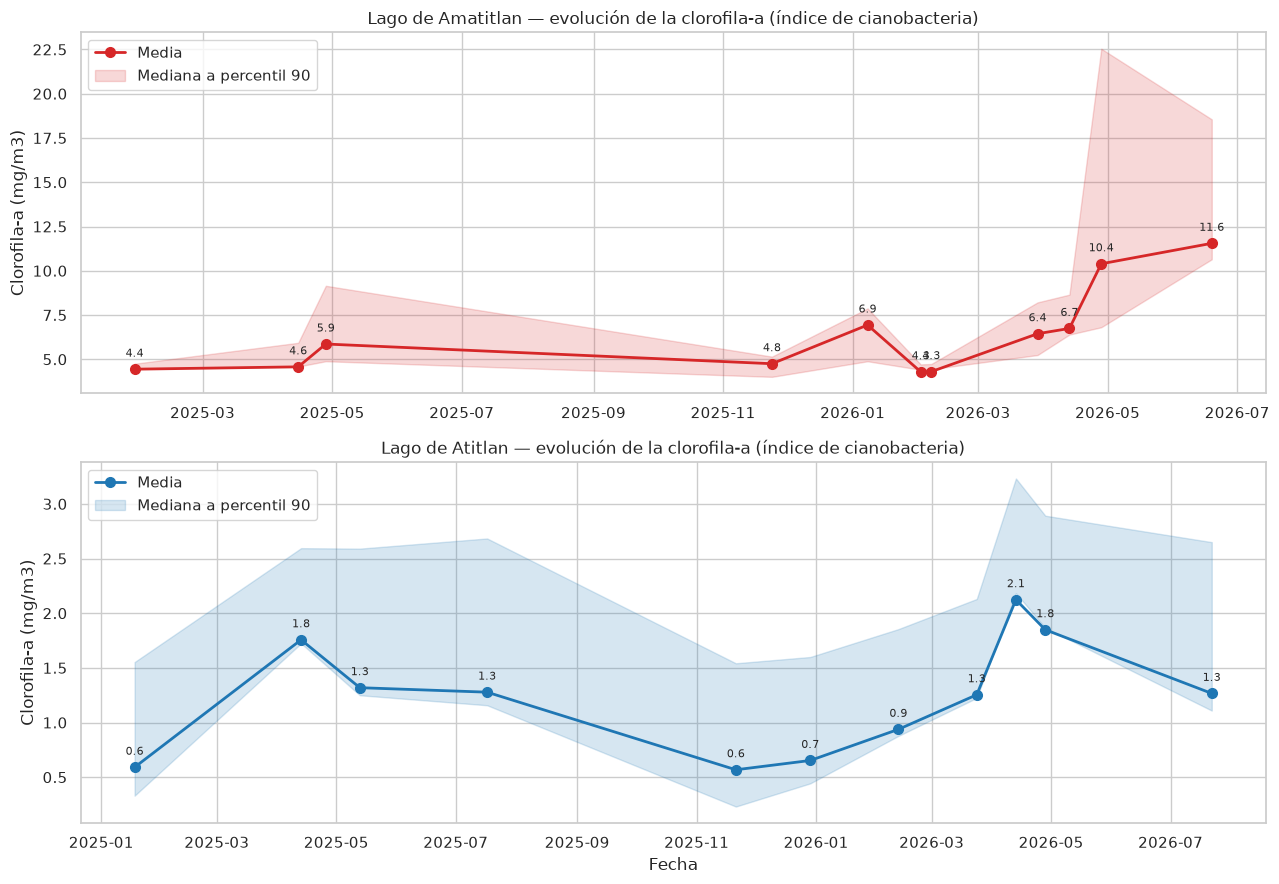

In [5]:
fig, ejes = plt.subplots(2, 1, figsize=(13, 9), sharex=False)

for eje, lago in zip(ejes, ["Amatitlan", "Atitlan"]):
    datos = tabla[tabla["lago"] == lago].sort_values("fecha")
    eje.plot(datos["fecha"], datos["chla_media"], "o-", color=COLOR[lago],
             linewidth=2, markersize=7, label="Media")
    eje.fill_between(datos["fecha"], datos["chla_mediana"], datos["chla_p90"],
                     color=COLOR[lago], alpha=0.18, label="Mediana a percentil 90")
    eje.set_title(f"Lago de {lago} — evolución de la clorofila-a (índice de cianobacteria)")
    eje.set_ylabel("Clorofila-a (mg/m3)")
    eje.legend()
    for _, fila in datos.iterrows():
        eje.annotate(f"{fila['chla_media']:.1f}",
                     (fila["fecha"], fila["chla_media"]),
                     textcoords="offset points", xytext=(0, 9),
                     ha="center", fontsize=8)

ejes[-1].set_xlabel("Fecha")
plt.tight_layout()
plt.show()

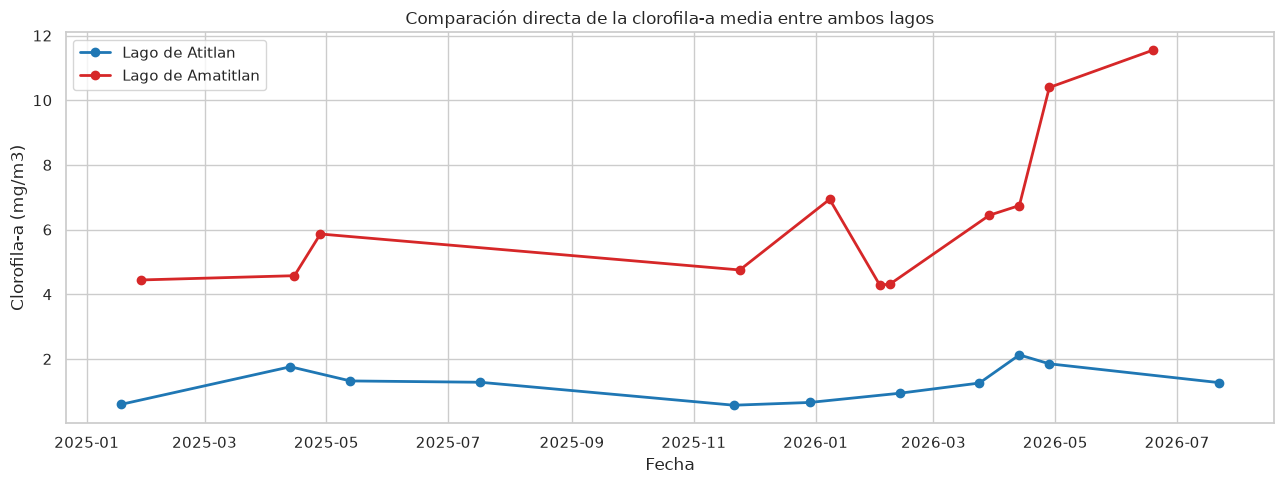

In [6]:
fig, eje = plt.subplots(figsize=(13, 5))
for lago in LAGOS:
    datos = tabla[tabla["lago"] == lago].sort_values("fecha")
    eje.plot(datos["fecha"], datos["chla_media"], "o-", color=COLOR[lago],
             linewidth=2, label=f"Lago de {lago}")
eje.set_title("Comparación directa de la clorofila-a media entre ambos lagos")
eje.set_ylabel("Clorofila-a (mg/m3)")
eje.set_xlabel("Fecha")
eje.legend()
plt.tight_layout()
plt.show()

### 4.3 Picos de floración y fechas críticas

Se considera **fecha crítica** aquella cuya clorofila-a media supera la media del lago más una desviación estándar. Es un criterio relativo a cada lago (debido a sus niveles base son muy distintos).

In [7]:
filas = []
for lago in LAGOS:
    datos = tabla[tabla["lago"] == lago].sort_values("fecha").copy()
    umbral = datos["chla_media"].mean() + datos["chla_media"].std()
    datos["critica"] = datos["chla_media"] > umbral
    print(f"{lago}: media = {datos['chla_media'].mean():.2f} mg/m3, "
          f"desv. est. = {datos['chla_media'].std():.2f}, umbral = {umbral:.2f} mg/m3")
    print("  Pico maximo    :", datos.loc[datos['chla_media'].idxmax(), 'fecha'].date(),
          f"({datos['chla_media'].max():.2f} mg/m3)")
    print("  Minimo         :", datos.loc[datos['chla_media'].idxmin(), 'fecha'].date(),
          f"({datos['chla_media'].min():.2f} mg/m3)")
    criticas = datos.loc[datos["critica"], "fecha"].dt.date.tolist()
    print("  Fechas criticas:", criticas if criticas else "ninguna")
    print()
    filas.append(datos)

criticas_tabla = pd.concat(filas)
criticas_tabla[criticas_tabla["critica"]][
    ["lago", "fecha", "chla_media", "chla_p90", "pct_alto", "nubosidad_pct"]
].round(2)

Atitlan: media = 1.24 mg/m3, desv. est. = 0.52, umbral = 1.76 mg/m3
  Pico maximo    : 2026-04-13 (2.12 mg/m3)
  Minimo         : 2025-11-21 (0.57 mg/m3)
  Fechas criticas: [datetime.date(2026, 4, 13), datetime.date(2026, 4, 28)]

Amatitlan: media = 6.39 mg/m3, desv. est. = 2.49, umbral = 8.88 mg/m3
  Pico maximo    : 2026-06-19 (11.55 mg/m3)
  Minimo         : 2026-02-02 (4.29 mg/m3)
  Fechas criticas: [datetime.date(2026, 4, 28), datetime.date(2026, 6, 19)]



,lago,fecha,chla_media,chla_p90,pct_alto,nubosidad_pct
19,Atitlan,2026-04-13,2.12,3.23,0.00,0.01
20,Atitlan,2026-04-28,1.85,2.89,0.00,4.96
9,Amatitlan,2026-04-28,10.39,22.54,13.65,4.96
10,Amatitlan,2026-06-19,11.55,18.55,7.51,13.00


Antes de interpretar conviene descartar que las subidas se deban a la calidad de la imagen y no al agua. Se revisa si la clorofila-a media se relaciona con la nubosidad reportada y con el porcentaje del lago que quedó libre de nubes.

In [8]:
for lago in LAGOS:
    datos = tabla[tabla["lago"] == lago]
    r_nubes, p_nubes = stats.pearsonr(datos["nubosidad_pct"], datos["chla_media"])
    r_cob, p_cob = stats.pearsonr(datos["cobertura_valida_pct"], datos["chla_media"])
    print(f"{lago:10s} nubosidad vs chla_media : r = {r_nubes:+.3f} (p = {p_nubes:.4f})")
    print(f"{' ':10s} cobertura vs chla_media : r = {r_cob:+.3f} (p = {p_cob:.4f})")

Atitlan    nubosidad vs chla_media : r = +0.004 (p = 0.9902)
           cobertura vs chla_media : r = +0.484 (p = 0.1317)
Amatitlan  nubosidad vs chla_media : r = +0.864 (p = 0.0006)
           cobertura vs chla_media : r = -0.288 (p = 0.3902)


### 4.4 Interpretación de los patrones temporales

**La proliferación no crece ni decrece de forma sostenida, fluctúa siguiendo un ciclo anual.** Los dos lagos suben y bajan varias veces dentro del período, pero lo hacen en momentos parecidos del año.

**Lago de Amatitlán**

Durante 2025 y el inicio de 2026 la clorofila-a media se mantiene en una banda estrecha, entre 4.29 y 6.94 mg/m³. A partir de marzo de 2026 la curva se dispara: 6.44 (29 de marzo), 6.74 (13 de abril), **10.40 (28 de abril)** y **11.55 (19 de junio)**, el valor más alto de toda la serie. Las dos últimas son las **fechas críticas** del lago, porque superan el umbral de media más una desviación estándar (8.88 mg/m³). La banda sombreada del gráfico muestra que en esas fechas el percentil 90 llega a 22.5 mg/m³, es decir, la décima parte más cargada del lago ya está por encima del umbral de riesgo de la OMS. El mínimo se da el 2 de febrero de 2026 (4.29 mg/m³).

**Lago de Atitlán**

Se mueve en un rango casi diez veces menor, entre 0.57 y 2.12 mg/m³, pero con una forma de onda muy marcada y repetida en los dos años: sube de 0.59 (enero 2025) a 1.76 (abril 2025), baja hasta su mínimo de 0.57 (noviembre 2025), vuelve a subir hasta su **máximo de 2.12 (13 de abril de 2026)** y desciende otra vez a 1.27 en julio de 2026. Sus fechas críticas son el 13 y el 28 de abril de 2026.

**Momento de los Picos**

En los dos lagos los máximos caen entre abril y junio, y los mínimos entre noviembre y febrero. Esa coincidencia apunta a factores comunes de la época. El final de la estación seca deja el agua más caliente, con poca mezcla vertical y mucha radiación solar, condiciones que favorecen a las cianobacterias; y las primeras lluvias de mayo y junio arrastran hacia el lago los nutrientes acumulados en la cuenca.

**Control de Calidad**

La revisión anterior muestra que en Atitlán la clorofila-a media no tiene relación con la nubosidad (r = +0.004, p = 0.99) y su relación con la cobertura válida no es significativa (r = +0.48, p = 0.13), de modo que su señal es limpia. En Amatitlán, en cambio, la correlación con la nubosidad es alta (r = +0.86). La fecha del pico, 19 de junio de 2026, es también la de mayor nubosidad (13%). Esto no invalida el pico (el 28 de abril tiene un valor casi igual con apenas 4.96% de nubes, y ambas fechas conservan más del 94% de cobertura válida), pero conviene tomar el valor de junio como un límite superior.

---

## Ejercicio 5 — Análisis espacial

### 5.1 Distribución de la cianobacteria dentro de cada lago

Cada mapa muestra la clorofila-a estimada píxel a píxel, únicamente dentro del espejo de agua. La escala de color es distinta para cada lago (Amatitlán está en un rango mucho más alto), pero es la misma para todas las fechas de un mismo lago, de modo que los mapas sí son comparables entre sí.

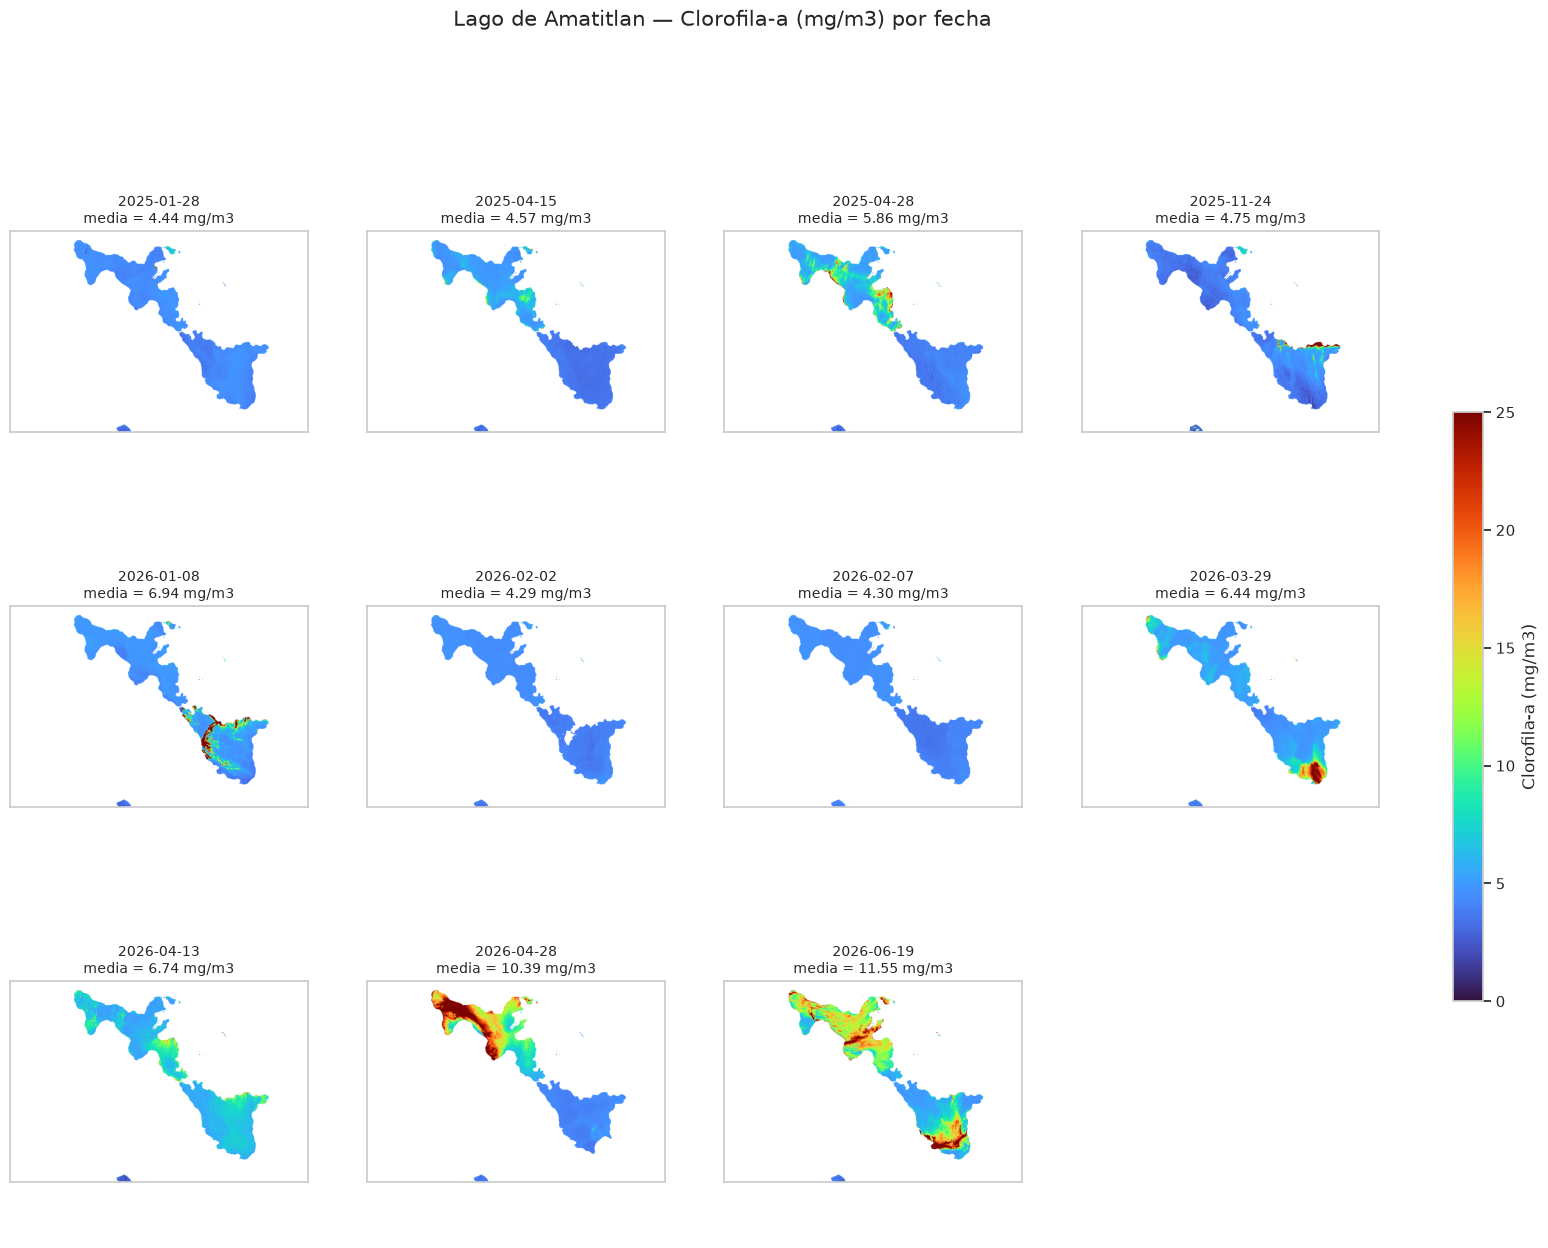

In [9]:
ESCALA = {"Atitlan": (0, 5), "Amatitlan": (0, 25)}


def grilla_mapas(lago, clave="chla", titulo="Clorofila-a (mg/m3)", cmap="turbo"):
    fechas = config.FECHAS[lago]
    vmin, vmax = ESCALA[lago]
    filas = int(np.ceil(len(fechas) / 4))
    fig, ejes = plt.subplots(filas, 4, figsize=(19, 4.6 * filas))
    ejes = np.atleast_1d(ejes).ravel()

    for eje, fecha in zip(ejes, fechas):
        img = eje.imshow(mapa_capa(lago, fecha, clave), cmap=cmap,
                         vmin=vmin, vmax=vmax, extent=extension[lago])
        media = tabla.query("lago == @lago and fecha == @fecha")["chla_media"].iloc[0]
        eje.set_title(f"{fecha}\nmedia = {media:.2f} mg/m3", fontsize=10)
        eje.set_xticks([])
        eje.set_yticks([])
    for eje in ejes[len(fechas):]:
        eje.axis("off")

    fig.colorbar(img, ax=ejes.tolist(), fraction=0.02, label=titulo)
    fig.suptitle(f"Lago de {lago} — {titulo} por fecha", fontsize=15, y=1.0)
    plt.show()


grilla_mapas("Amatitlan")

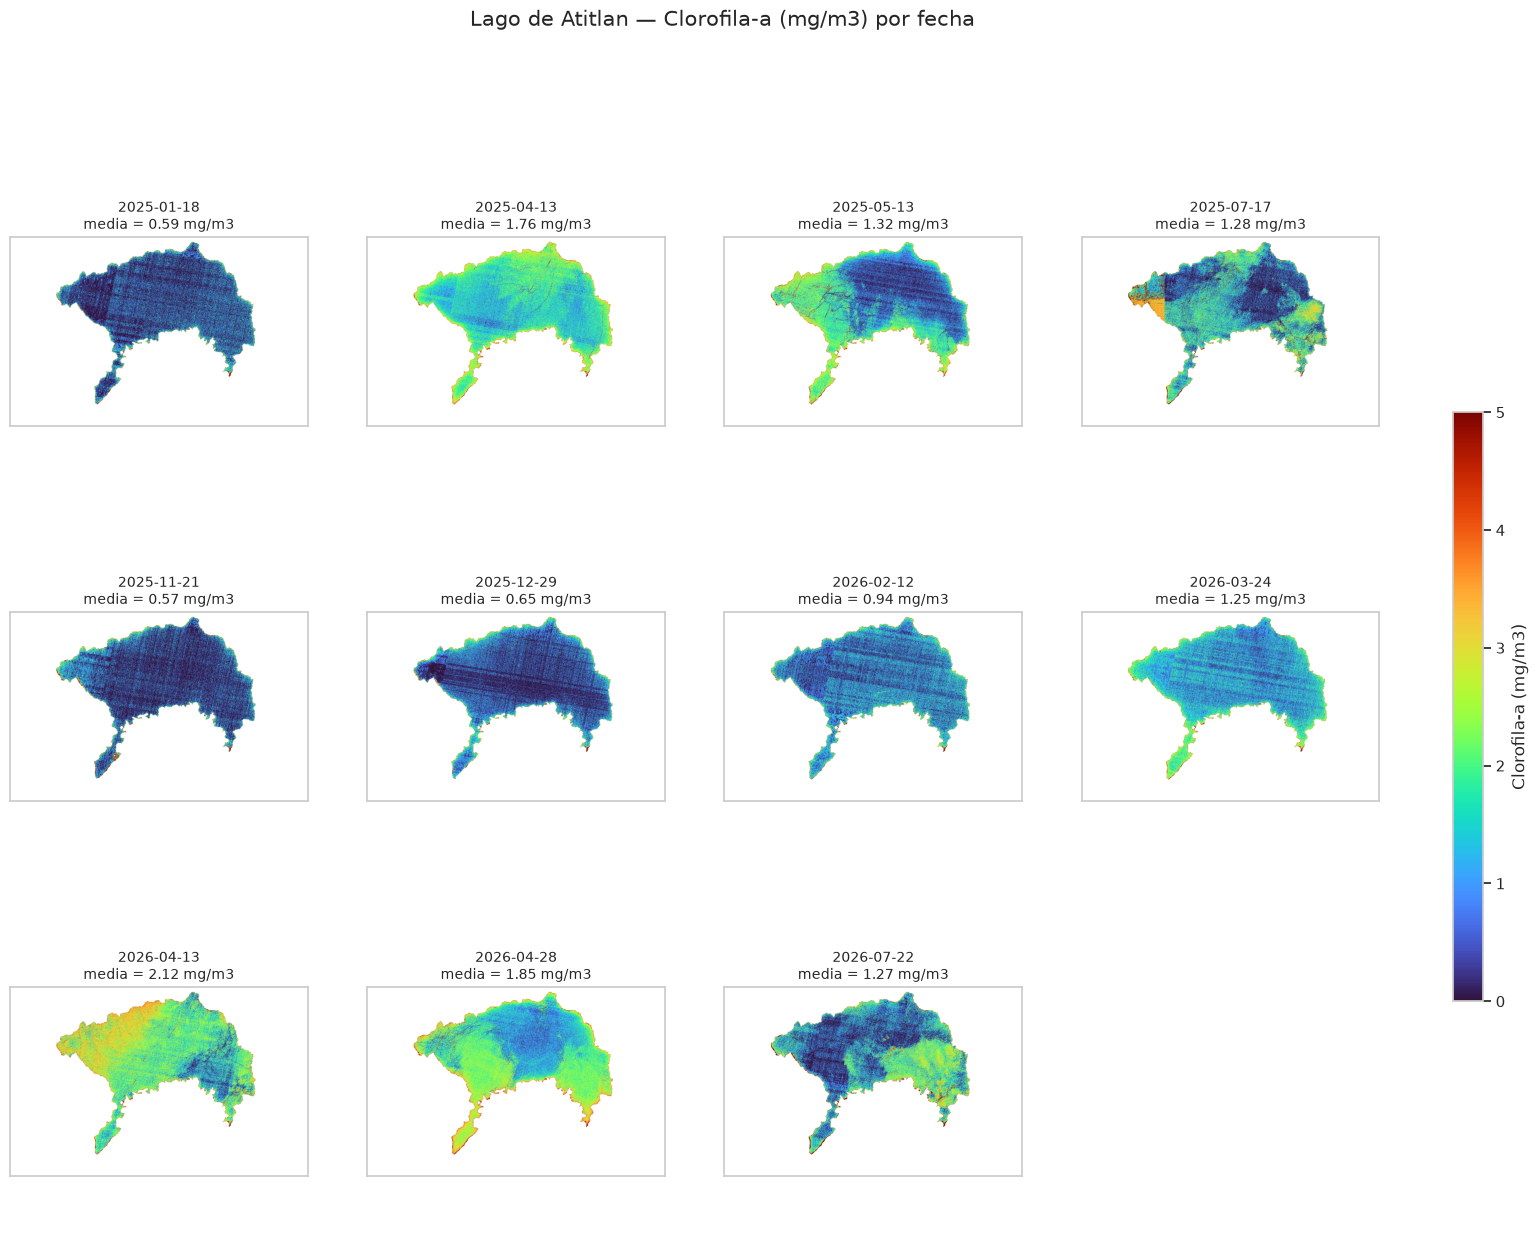

In [10]:
grilla_mapas("Atitlan")

### Mapa interactivo (folium)

Para explorar los valores sobre una base cartográfica real se genera un mapa interactivo
con tres fechas por lago: la de menor carga, una intermedia y la del pico. Las capas se
activan y desactivan con el control de la esquina superior derecha.

Atitlan -> ['2025-11-21', '2026-04-13', '2026-07-22']
Amatitlan -> ['2025-04-28', '2026-02-02', '2026-06-19']



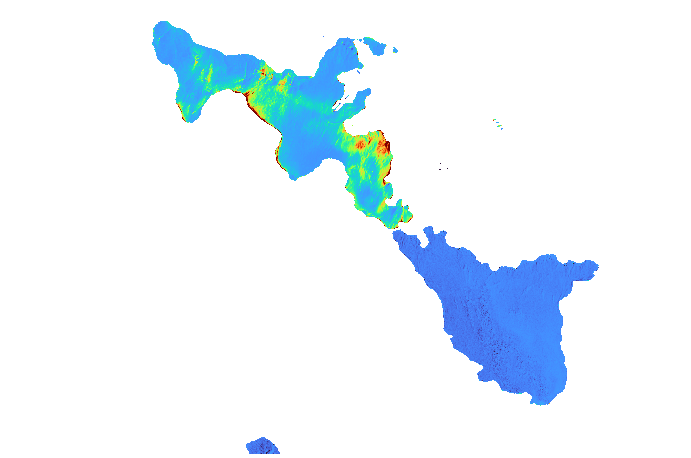
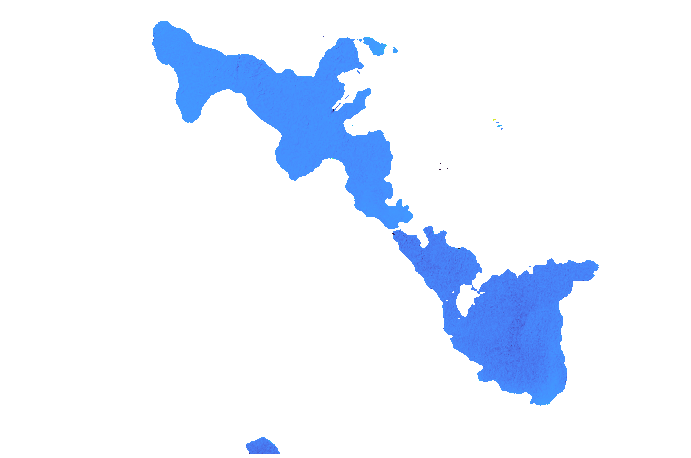
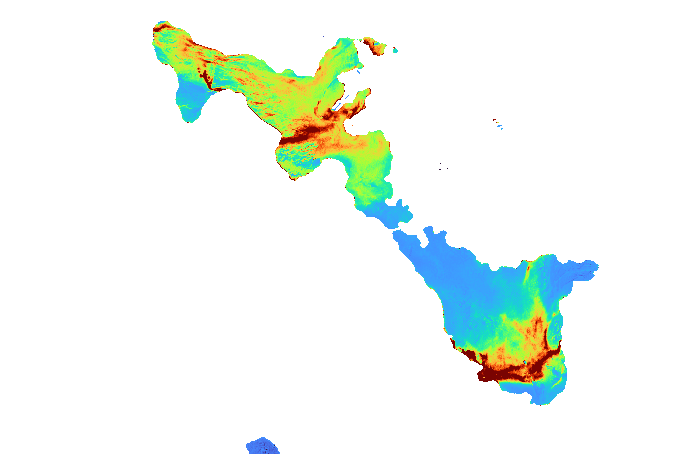

In [11]:
def mapa_interactivo(lago, fechas):
    vmin, vmax = ESCALA[lago]
    mapa = folium.Map(location=mp.centro(procesar.ruta_cruda(lago, fechas[0])),
                      zoom_start=13, tiles="OpenStreetMap")

    for fecha in fechas:
        capa, limites = mp.a_wgs84(mapa_capa(lago, fecha),
                                   procesar.ruta_cruda(lago, fecha))
        folium.raster_layers.ImageOverlay(
            image=mp.a_rgba(capa, vmin, vmax),
            bounds=limites,
            opacity=0.75,
            name=f"Clorofila-a {fecha}",
        ).add_to(mapa)

    folium.LayerControl(collapsed=False).add_to(mapa)
    return mapa


seleccion = {}
for lago in LAGOS:
    datos = tabla[tabla["lago"] == lago].sort_values("chla_media")
    seleccion[lago] = sorted([
        datos["fecha"].iloc[0].strftime("%Y-%m-%d"),
        datos["fecha"].iloc[len(datos) // 2].strftime("%Y-%m-%d"),
        datos["fecha"].iloc[-1].strftime("%Y-%m-%d"),
    ])
    print(lago, "->", seleccion[lago])

mapa_interactivo("Amatitlan", seleccion["Amatitlan"])


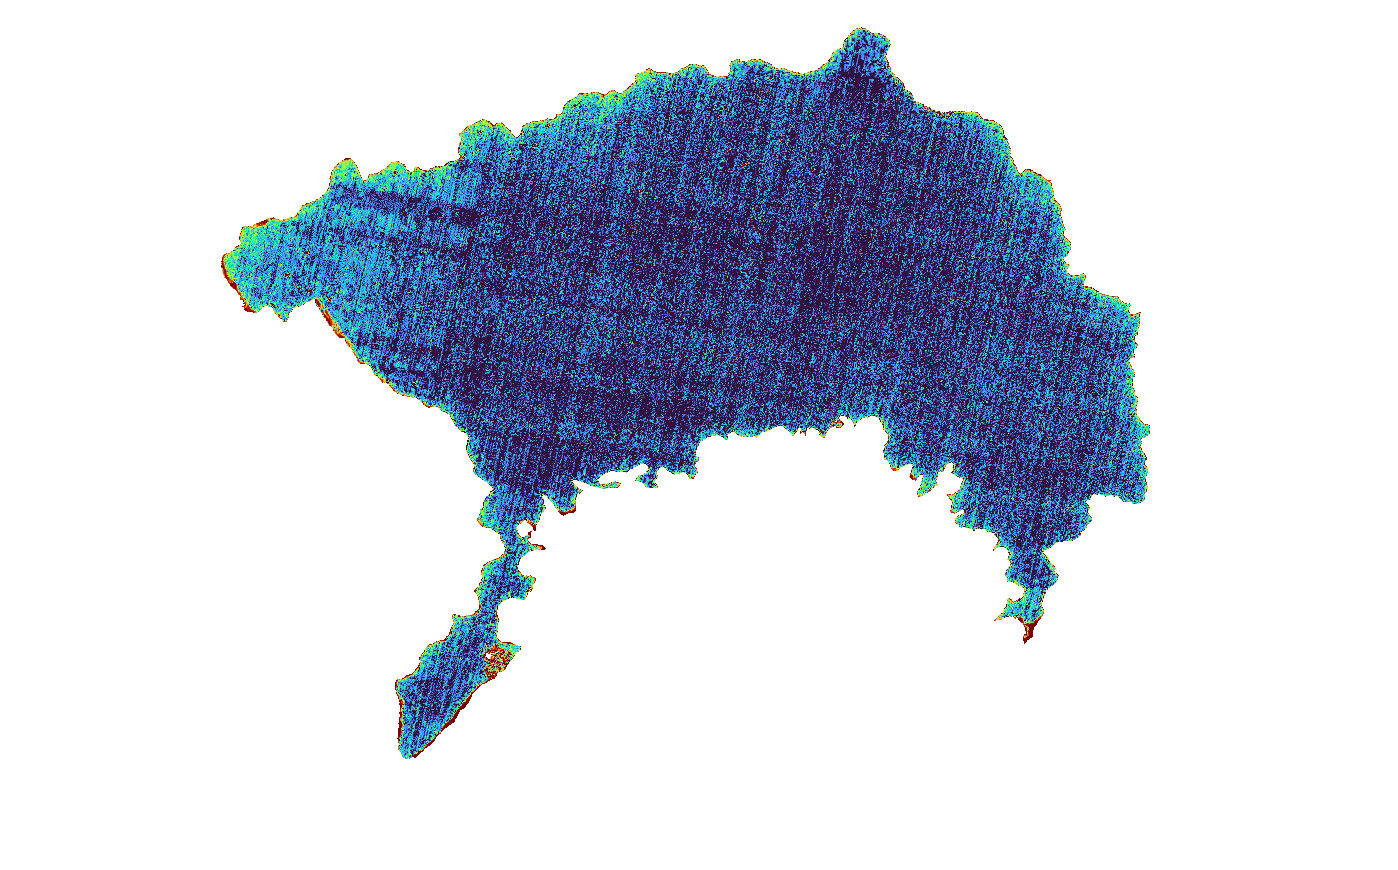
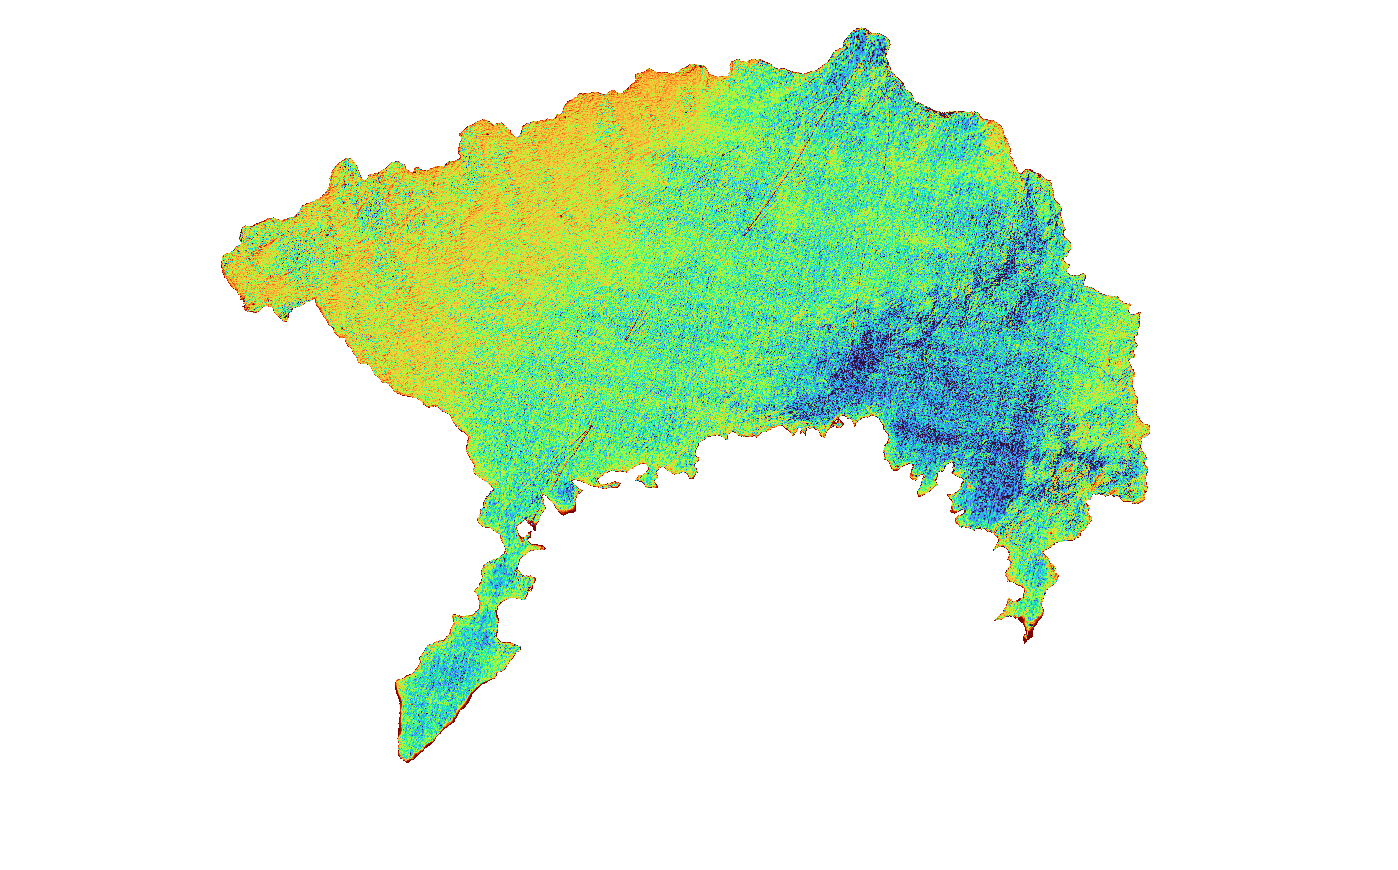
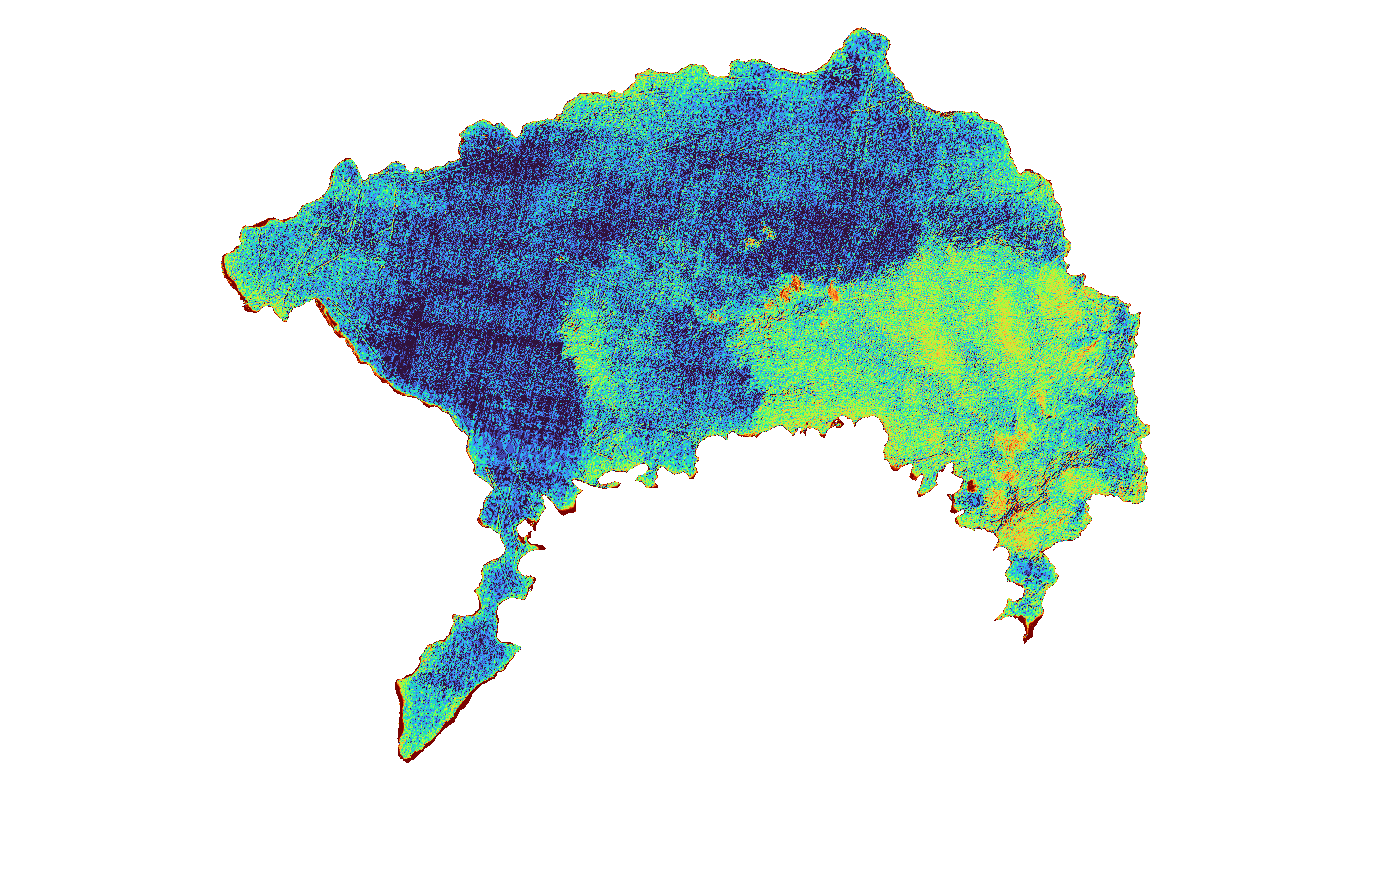

In [12]:
mapa_interactivo("Atitlan", seleccion["Atitlan"])

### 5.2 Mapas comparativos entre fechas

Se comparan la fecha de menor carga y la del pico de cada lago, y se calcula el **mapa de diferencia** (pico menos mínimo). El rojo indica dónde aumentó la clorofila-a y el azul dónde disminuyó.

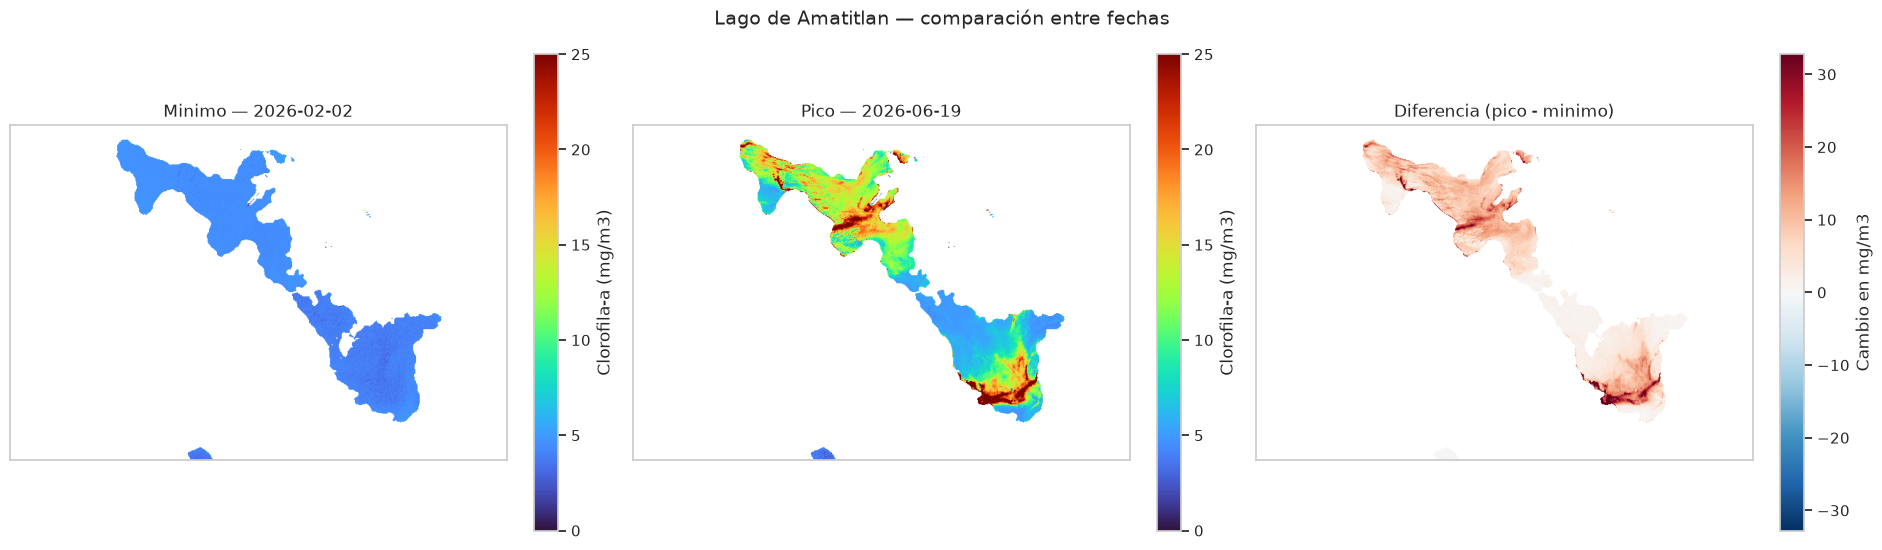

Cambio medio en el lago: +7.44 mg/m3   |   pixeles del lago que aumentaron: 99.2%


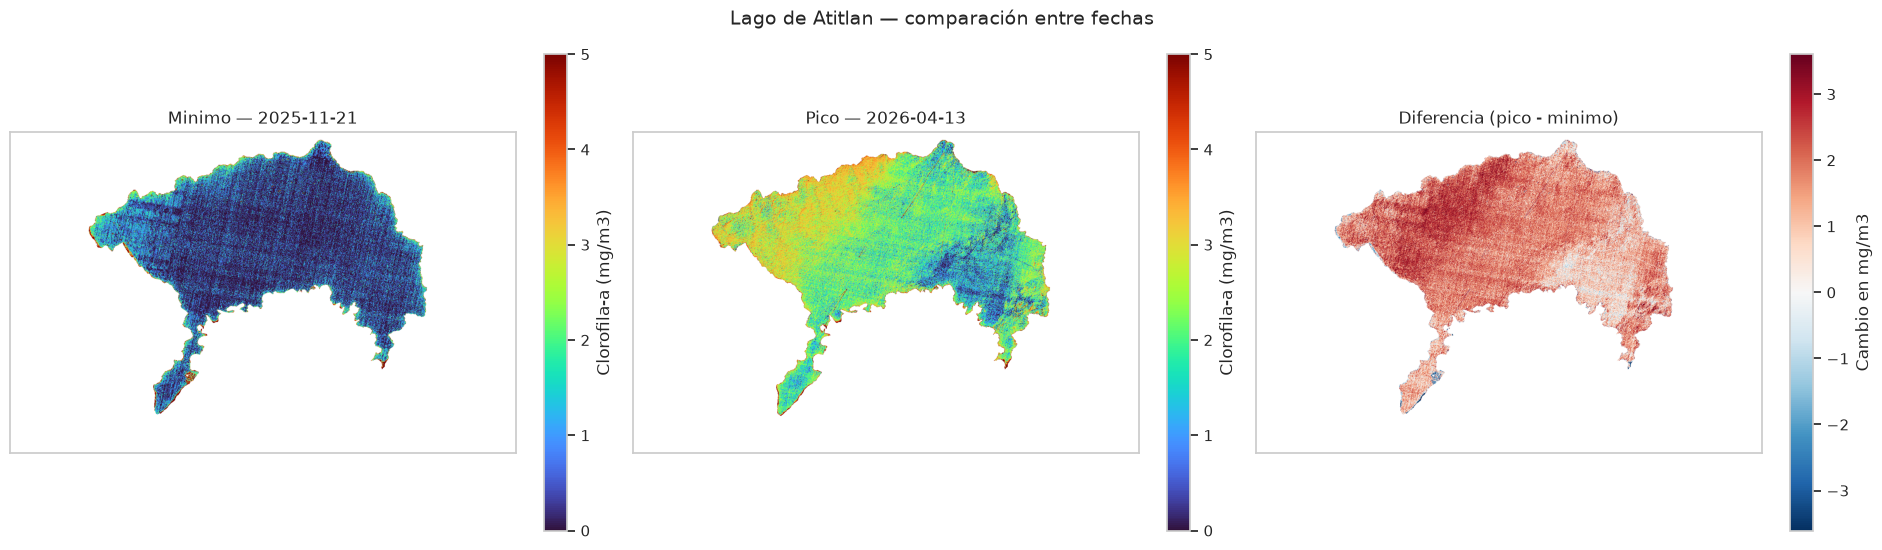

Cambio medio en el lago: +1.56 mg/m3   |   pixeles del lago que aumentaron: 91.0%


In [13]:
def comparar_fechas(lago, fecha_baja, fecha_alta):
    vmin, vmax = ESCALA[lago]
    baja = mapa_capa(lago, fecha_baja)
    alta = mapa_capa(lago, fecha_alta)
    diferencia = alta - baja
    limite = np.nanpercentile(np.abs(diferencia), 99)

    fig, ejes = plt.subplots(1, 3, figsize=(19, 5.5))
    for eje, capa, titulo in [
        (ejes[0], baja, f"Minimo — {fecha_baja}"),
        (ejes[1], alta, f"Pico — {fecha_alta}"),
    ]:
        img = eje.imshow(capa, cmap="turbo", vmin=vmin, vmax=vmax,
                         extent=extension[lago])
        eje.set_title(titulo)
        eje.set_xticks([]); eje.set_yticks([])
        fig.colorbar(img, ax=eje, fraction=0.046, label="Clorofila-a (mg/m3)")

    img = ejes[2].imshow(diferencia, cmap="RdBu_r", vmin=-limite, vmax=limite,
                         extent=extension[lago])
    ejes[2].set_title("Diferencia (pico - minimo)")
    ejes[2].set_xticks([]); ejes[2].set_yticks([])
    fig.colorbar(img, ax=ejes[2], fraction=0.046, label="Cambio en mg/m3")

    fig.suptitle(f"Lago de {lago} — comparación entre fechas", fontsize=14)
    plt.tight_layout()
    plt.show()

    dentro = diferencia[np.isfinite(diferencia)]
    print(f"Cambio medio en el lago: {dentro.mean():+.2f} mg/m3   |   "
          f"pixeles del lago que aumentaron: {(dentro > 0).mean() * 100:.1f}%")


for lago in ["Amatitlan", "Atitlan"]:
    datos = tabla[tabla["lago"] == lago].sort_values("chla_media")
    comparar_fechas(lago,
                    datos["fecha"].iloc[0].strftime("%Y-%m-%d"),
                    datos["fecha"].iloc[-1].strftime("%Y-%m-%d"))

### 5.3 Interpretación de los patrones espaciales

**Lago de Amatitlán**

El lago tiene forma alargada, con una cuenca al noroeste y otra al sureste separadas por un estrechamiento. Los mapas muestran que **la cuenca noroeste es siempre la más cargada**. En las fechas tranquilas (2026-02-02, 2026-02-07) todo el lago está por debajo de 5 mg/m³ y se ve azul uniforme; en cuanto la carga sube, el color caliente aparece primero en el ala noroeste (2025-04-28, 2026-04-13) y en los picos (2026-04-28, 2026-06-19) esa cuenca completa supera los 20 mg/m³ mientras la cuenca sureste apenas llega a 7. También se repiten focos intensos pegados a las orillas, el borde sur de la cuenca sureste se enciende el
2025-11-24, el 2026-03-29 y el 2026-06-19.

**Lago de Atitlán**

En este lago el patrón es completamente distinto. En prácticamente todas las fechas se ve una **franja delgada de valores altos que rodea todo el lago**, mientras el centro profundo es siempre la zona más limpia. La franja se ensancha en las bahías del sur y en el extremo suroriente. Lo que cambia entre fechas no
es tanto la orilla sino cuánto se "enciende" el interior. El 2025-11-21 y el 2025-12-29 el lago entero está cerca de 0.6 mg/m³, mientras que el 2026-04-13 y el 2026-04-28 la mitad occidental sube a 2–3 mg/m³ y solo el sector nororiental se mantiene bajo.

**Cambio entre Fechas**

Los mapas de diferencia son casi enteramente rojos; al pasar del mínimo al pico, la clorofila-a sube en la gran mayoría del espejo de agua de los dos lagos. En Amatitlán el aumento medio es de unos +7 mg/m³, concentrado en la cuenca noroeste, y en Atitlán de alrededor de +1.5 mg/m³, repartido de forma más pareja.

**Áreas Persistentes**

Las dos zonas que se repiten fecha tras fecha son la **cuenca noroeste de Amatitlán** y el **anillo litoral de Atitlán**.